In [1]:
import sys
print(sys.executable)

/Volumes/I/anaconda3-2025/anaconda3/envs/Mnist_env_new/bin/python


In [2]:
import pandas as pd


import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,Conv2D,MaxPooling2D,Flatten,Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt





In [3]:

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.1


In [4]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()


In [5]:
# train and test and reshape
X_train_flat = X_train.reshape(-1, 28*28).astype('float32') / 255.0
X_test_flat = X_test.reshape(-1, 28*28).astype('float32') / 255.0


In [6]:
print(X_test.shape)

(10000, 28, 28)


In [7]:
print("X_train reshaped shape:", X_train.reshape(-1, 28*28).astype('float32').shape)

X_train reshaped shape: (60000, 784)


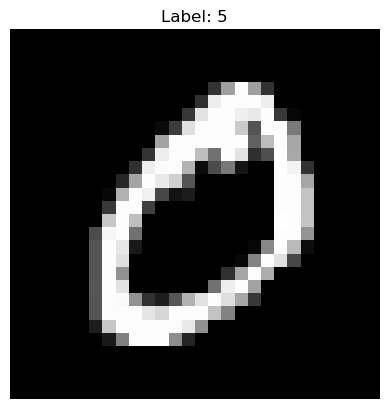

In [8]:
plt.imshow(X_train[1].reshape(28, 28), cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()

In [9]:
print("First 100 pixel values of first image:\n", X_train_flat[0][:100])


First 100 pixel values of first image:
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


In [10]:
# One-hot encode labels - train and test the letters
y_train_ohe = to_categorical(y_train, 10)
y_test_ohe  = to_categorical(y_test, 10)


In [11]:
model = Sequential([
    Input(shape=(28*28,)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])


In [12]:
# 4️⃣ Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [13]:
# 7️⃣ ✅ Define generator (place your code here)
def data_generator(X, y, batch_size=32):
    n = len(X)
    while True:
        for i in range(0, n, batch_size):
            yield X[i:i+batch_size], y[i:i+batch_size]

train_gen = data_generator(X_train_flat, y_train_ohe, batch_size=32)


In [ ]:

model.fit(train_gen, steps_per_epoch=len(X_train_flat)//32, epochs=8)

Epoch 1/8
